In [1]:
import numpy as np
import jax
from jax import Array, lax
import jax.numpy as jnp
import jax.random as jrnd
import sympy as sp
from jax.scipy.special import xlogy

import os, sys, pathlib
os.environ["OPENBLAS_NUM_THREADS"] = "1"
_project_root = pathlib.Path.cwd().resolve()
sys.path.insert(0, str(_project_root.parents[0]))
sys.path.insert(0, str(_project_root.parents[1]))
jax.config.update('jax_enable_x64', 'false')

from physics.markov import matrix_powers, H, KL, get_q_star, bound, bound2, mmc
from physics.glauber import dense_generator_from_rates, heat_rate_vectors
import physics.glauber as ising
from src.categorization import show_latex_bmatrix
from src.symmetry.permutations import perm_from_cycles, perm_hom

### MPL Config

In [2]:
import matplotlib as mpl
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
from matplotlib.axes import Axes

mpl.rcParams.update({
  "font.size": 16,
  "axes.titlesize": 20,
  "axes.labelsize": 16,
  "xtick.labelsize": 9,
  "ytick.labelsize": 9,
  "figure.dpi": 150,
  "savefig.dpi": 300,
  "pdf.fonttype": 42,
  "ps.fonttype": 42,
  "mathtext.fontset": "dejavusans",
  "text.usetex": True,
  "font.family": "Helvetica",
})


In [ ]:
from matplotlib.patches import Rectangle

r = Rectangle((0,0),10, 10)
r.set(edgecolor="tab:green", linewidth=2.2, zorder=3)


2.2


In [ ]:
from matplotlib.collections import LineCollection, PatchCollection

theta = np.linspace(0, np.pi, 36)
radii = np.linspace(4, 5, num=10)
arcs = [np.column_stack([r * np.cos(theta), r * np.sin(theta)]) for r in radii]

c = LineCollection(arcs)

c.set(color=np.zeros((10, 3)), )
print(c._edgecolors)


[[0. 0. 0. 1.]
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]]


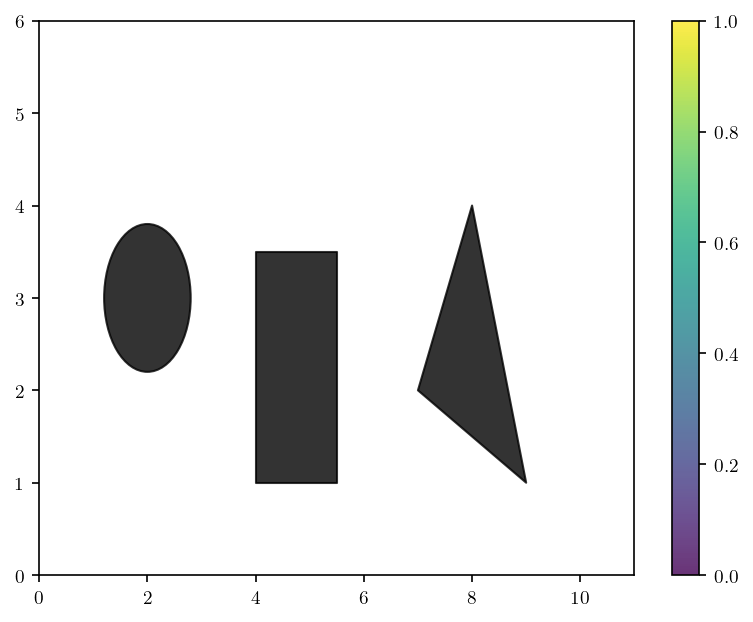

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Rectangle, Polygon
from matplotlib.collections import PatchCollection

# 1. Create a figure and axis object
fig, ax = plt.subplots()

# 2. Build a list of heterogeneous shapes
shapes = [
    Circle((2, 3), radius=0.8),
    Rectangle((4, 1), width=1.5, height=2.5),
    Polygon(np.array([[7, 2], [8, 4], [9, 1]]))
]

# 3. Package the shapes into a PatchCollection
# We omit individual colors here so they can be mapped via data array instead
collection = PatchCollection(shapes, alpha=0.8)

# 4. Assign scalar values to each shape to map against the colormap
# The array must have the same length as the number of patches
values = np.array([10, 50, 90])
# collection.set_array(values)
collection.set(facecolor=np.zeros((3, 3)), edgecolor=np.zeros((3, 3)))

# 5. Add the collection to the plot and adjust views
ax.add_collection(collection)

# Explicitly tell Matplotlib to auto-scale limits around the new data collection
ax.set_xlim(0, 11)
ax.set_ylim(0, 6)

# 6. Add a colorbar tied to the collection values
fig.colorbar(collection, ax=ax)

plt.show()


### Funcs

In [ ]:
from scipy.optimize import minimize

def q_from_theta(theta: Array) -> Array:
  # theta has length 2; fix the third logit to zero
  logits = jnp.concatenate([theta, jnp.zeros(1, dtype=theta.dtype)])
  return jax.nn.softmax(logits)

def make_objective(n_steps):
  def objective(theta: Array) -> Array:
    q = q_from_theta(theta)
    return mmc(q, G, p0, n_steps)
  # Compile the objective and its exact JAX gradient
  value_and_grad = jax.jit(jax.value_and_grad(objective))
  def scipy_objective(theta_np):
    value, gradient = value_and_grad(jnp.asarray(theta_np))
    return (float(value), np.asarray(gradient, dtype=np.float64))
  return scipy_objective


### 3-state Toy Example 1

In [ ]:
d = 3
φ = 0.01
G = jnp.array([
  [1 - φ, φ, 0],
  [0, 1 - φ, φ],
  [φ, 0, 1 - φ]
])
# p0 = jnp.ones((d,))/d
p0 = jrnd.uniform(key, (d,))
p0 = p0 / jnp.sum(p0)

In [ ]:
G_min = np.array([
  [1-p, 1-p],
  [p, p]
])

G_mem1 = np.array([
  [1-p, 0,   1-p, 0],
  [p,   0,   p,   0],
  [0,   1-p, 0,   1-p],
  [0,   p,   0,   p],
])

### 3-state Toy Example 2

In [ ]:
SIMPLEX_VERTICES = np.array([
  [0.0, 0.0],
  [1.0, 0.0],
  [0.5, np.sqrt(3.0) / 2.0],
])

def simplex_to_cartesian(points):
  return np.asarray(points) @ SIMPLEX_VERTICES

def sample_simplex(levels=45):
  points = []
  for i in range(levels + 1):
    for j in range(levels + 1 - i):
      k = levels - i - j
      points.append((i / levels, j / levels, k / levels))
  return jnp.array(points, dtype=jnp.float32)

def regularize_simplex(points, eps=1e-3):
  # Keep KL terms finite near the simplex boundary without changing the plot mesh.
  points = jnp.clip(points, eps, None)
  return points / jnp.sum(points, axis=-1, keepdims=True)

def format_prob(point):
  return "(" + ", ".join(f"{x:.2f}" for x in np.asarray(point)) + ")"

def normalize_simplex_point(point):
  point = np.asarray(point)
  return point / point.sum()

def draw_simplex_frame(ax: Axes, color="0.25", lw=1.0):
  verts = SIMPLEX_VERTICES[[0, 1, 2, 0]]
  ax.plot(verts[:, 0], verts[:, 1], color=color, lw=lw, zorder=2)

def add_corner_labels(ax: Axes, fontsize=9, color="0.2"):
  ax.text(SIMPLEX_VERTICES[0,0] - 0.03, SIMPLEX_VERTICES[0,1] - 0.00,
          r"$(1,0,0)$", ha="right", va="top", fontsize=fontsize, color=color)
  ax.text(SIMPLEX_VERTICES[1,0] + 0.03, SIMPLEX_VERTICES[1,1] - 0.00,
          r"$(0,1,0)$", ha="left", va="top", fontsize=fontsize, color=color)
  ax.text(SIMPLEX_VERTICES[2,0], SIMPLEX_VERTICES[2,1] + 0.03,
          r"$(0,0,1)$", ha="center", va="bottom", fontsize=fontsize, color=color)



In [ ]:
# ---- data
n_values = (1, 10, 100, 500)

grid = sample_simplex(levels=60)
grid_eval = regularize_simplex(grid)
grid_xy = simplex_to_cartesian(grid)
triang = mtri.Triangulation(grid_xy[:, 0], grid_xy[:, 1])

mmc_by_n = {}
q_star_by_n = {}
for n in n_values:
  evaluator = jax.jit(jax.vmap(lambda q: mmc(q, G, p0, n)))
  mmc_by_n[n] = np.asarray(evaluator(grid_eval))
  q_star_by_n[n] = np.asarray(get_q_star(p0, G, n))

traj = np.array([get_q_star(p0, G, n) for n in range(1, n_values[-1] + 1)])
print(traj.shape)
traj_xy = simplex_to_cartesian(traj)


vmin=min(values.min() for values in mmc_by_n.values())
vmax=max(values.max() for values in mmc_by_n.values())


print(min(values.min() for values in mmc_by_n.values()))
norm = mcolors.SymLogNorm(linthresh=1e-2, vmin=vmin, vmax=vmax)

In [ ]:
# ---- figure
fig = plt.figure(figsize=(8.5,7.3), constrained_layout=True, dpi=300)
gs = fig.add_gridspec(2, 3, width_ratios=[1, 1, 0.06])

axs = [
  fig.add_subplot(gs[0, 0]),
  fig.add_subplot(gs[0, 1]),
  fig.add_subplot(gs[1, 0]),
  fig.add_subplot(gs[1, 1]),
]
cax = fig.add_subplot(gs[:, 2])

# fig, axes = plt.subplots(len(n_values) // 2, 2, figsize=(12, len(n_values) // 2 * 6), constrained_layout=True)
# axs: list[Axes] = np.array(axes).flatten().tolist()

panel_labels = ["(a)", "(b)", "(c)", "(d)"]


mappable = None
for i, (ax, n) in enumerate(zip(axs, n_values)):
  values = mmc_by_n[n]
  q_star = q_star_by_n[n]
  q_star_simplex = normalize_simplex_point(q_star)
  q_star_xy = simplex_to_cartesian(q_star_simplex)
  mappable = ax.tripcolor(triang,mmc_by_n[n],shading="gouraud",cmap="viridis",norm=norm,rasterized=True,)
  draw_simplex_frame(ax, color="0.20", lw=1.0)
  # add_corner_labels(ax, fontsize=8.5, color="0.25")
  # trajectory up to N
  ax.plot(traj_xy[:n, 0],traj_xy[:n, 1],color="white",lw=1.2,alpha=0.85,zorder=3,)
  ax.scatter(q_star_xy[0], q_star_xy[1], color="white", s=28, zorder=4)
  bbox = dict(
    boxstyle="round,pad=0.2", fc="white", ec="0.7", lw=0.6, alpha=0.7,
  )
  ax.annotate(
    rf"$q^* = {format_prob(q_star)}$", xy=q_star_xy + np.array([0.02, -0.1]),
    xytext=(6, 6), textcoords="offset points", fontsize=16, color="k", bbox=bbox, zorder=5,
  )

  ax.text(0.02, 0.97, panel_labels[i], transform=ax.transAxes, ha="left", va="top", fontsize=16, color="0.15")
  ax.set_title(rf"$N = {n}$", pad=4)
  ax.set(aspect='equal', xlim=(-0.01, 1.01),  ylim=(-0.01, SIMPLEX_VERTICES[2, 1] + 0.01))
  ax.axis("off")

cb = fig.colorbar(mappable, cax=cax)
cb.set_label(r"$\mathcal{M}_N(q;G,p_0)$", rotation=90, labelpad=10) # fontsize=14
cb.ax.tick_params(labelsize=16)

fig.savefig('simplex_heatmap.pdf')
plt.show()

### 4-State DFA

One way to check for islands for a contindional distribution $G(y|x)$ is if we compute the pairwise inner products of its columns. If $G$ is an $n\times n$ matrix, then there are $n^2$ such computations, and, indeed, the entries of the **gram matrix** $G^\top G$ are exactly the pairwise inner products. 

$x$ and $x'$ lie on the same island if there is a path between them, i.e., there is some power of $A$ such that $A_{xx'}>0$

In [ ]:
d = 4
N = 10
key = jrnd.PRNGKey(0)

def make_dfa_G(pa):
  pb = 1 - pa
  G = jnp.array([
    [pa, pb, 0.0, 0.0], 
    [pa, 0.0, pb, 0.0], 
    [pa, 0.0, 0.0, pb], 
    [0.0, 0.0, 0.0, pa + pb],
  ]).T
  return G

G = make_dfa_G(0.75)
# connected components
A = (G.T @ G > 0)
# initial state delta on r_0
p0 = jnp.array([1.0, 0.0, 0.0, 0.0])
# x and x' lie on the same island if there is a path between them, i.e., there is some power of $A$ such that $A_{xx'}>0$
# isl = jnp.where(jnp.sum(matrix_powers(A, d-1)))
n_steps = 100
obj = lambda q: mmc(q, G, p0, n_steps)


In [ ]:
from functools import partial
@partial(jax.jit, static_argnames=("N_max",))
def get_traj(G, p0, N_max):
  # p <- G @ p
  def traj(p, x):
    return G @ p, p # one mat-vec per step, not mat-mat
  pN, pts = lax.scan(traj, init=p0, length=N_max)
  return pN, jnp.concatenate((pts, pN[None]))

In [ ]:
p = 0.1
print(jnp.kron(jnp.eye(4), jnp.array([[1-p, 1-p], [p, p]])))


Note that 
$$
\pi_m = [1-p, p]^{\otimes m}\quad\text{and}\quad p_{0,m} = [1,0]^{\otimes m}
$$
Also,
$$
D(p_1\otimes p_2 \|q_1\otimes q_2) = D(p_1\|q_1) + D(p_2 \| q_2),
$$
so 
$$
D(p_0^{(m)}\|\pi_m) = -m\log(1-p)
$$
In fact, $G_m$ reaches stationarity in exactly $m$ steps
$$

$$

In [ ]:
def make_mbit_memory_G(m, p):
  n = 2**m

  A0 = jnp.zeros((n, n))
  A1 = jnp.zeros((n, n))

  for x in range(n):
    # retain the last m-1 bits
    tail = x & (2**(m-1) - 1)

    next0 = (tail << 1) | 0
    next1 = (tail << 1) | 1

    A0 = A0.at[next0, x].set(1.0)
    A1 = A1.at[next1, x].set(1.0)
  return (1-p) * A0 + p * A1

def stationary_mbit(m, p):
  pi = jnp.array([1 - p, p])
  for _ in range(m - 1):
    pi = jnp.kron(pi, jnp.array([1 - p, p]))
  return pi

def last_bit_projection(m):
  n = 2**m
  C = jnp.zeros((2, n))
  for x in range(n):
    bit = x & 1
    C = C.at[bit, x].set(1.0)
  return C

Flipping last bit:
$$
x\mapsto x\oplus 1,
$$
so construct a graph with only one allowed flip per state:

In [ ]:
def make_memory_write_transition(m, b, Delta):
  n = 2**m
  states = jnp.arange(n)

  # Flip least-significant bit = most recent memory bit
  rows = jnp.array([states ^ 1])  # shape (1, n)

  if b == 0:
    E_bit = jnp.array([0.0, Delta])
  else:
    E_bit = jnp.array([Delta, 0.0])

  last_bit = states & 1
  E = E_bit[last_bit]

  # energy change source -> flipped destination
  dE = E[rows] - E[None, :]      # shape (1, n)

  return rows, dE, E

def rates_from_dE(dE, beta, gamma=1.0):
  return gamma * jnp.exp(-0.5 * beta * dE)

In [ ]:
import jax.scipy.linalg as jsp

def bit_write_generator(b, beta=1.0, Delta=5.0, gamma=1.0):
  # target b has low energy
  E = Delta * (jnp.arange(2) != b)

  dE = E[:, None] - E[None, :]

  K = gamma * jnp.exp(-0.5 * beta * dE)
  K = K.at[jnp.diag_indices(2)].set(0.0)

  # column-generator convention
  K = K.at[jnp.diag_indices(2)].set(-K.sum(axis=0))

  pi = jnp.exp(-beta * E)
  pi = pi / pi.sum()

  return K, pi


def cyclic_shift_matrix(m):
  n = 2**m
  S = jnp.zeros((n, n))

  for x in range(n):
    first = (x >> (m - 1)) & 1
    tail = x & (2**(m - 1) - 1)

    y = (tail << 1) | first
    S = S.at[y, x].set(1.0)

  return S


def make_physical_mbit_branch(m, b, tau, beta=1.0,
                            Delta=5.0, gamma=1.0):
  Kb, pi_b = bit_write_generator(
      b, beta=beta, Delta=Delta, gamma=gamma
  )
  rows, dE, E = make_memory_write_transition(m, b, Delta)
  rates = rates_from_dE(dE, beta, 1.0)
  K = dense_generator_from_rates(rows, rates)

  # one bath,
  g = heat_rate_vectors(rates[None, :, :], dE)
  EM_dt, A = ising.precompute_ep(
    K, g, tau
  )
  c = jnp.array([beta]) @ A

  Rb = jsp.expm(tau * Kb)
  S = cyclic_shift_matrix(m)

  G_b = jnp.kron(jnp.eye(2**(m-1)), Rb) @ S

  # print(G_b - jsp.expm(tau * K) @ S)
  A_cycle = A[0] @ S
  c_cycle = c @ S
  return G_b, pi_b, A_cycle, c_cycle

In [ ]:
def get_stuff(G: Array, p0: Array, N_max):
  pN, pts = get_traj(G, p0, N_max)
  p_avgs = jnp.cumsum(pts[:-1], axis=0) / Ns[:, None]
  Gp_avgs = p_avgs @ G.T
  landauer = - H(pts[1:], axis=1) + H(p0)
  pmmcs = - landauer + Ns * (H(p_avgs, axis=1) - H(Gp_avgs, axis=1))
  vals, vecs = np.linalg.eig(G) 
  idx = np.argmin(np.abs(vals - 1.0))
  pi  = np.real(vecs[:, idx])
  pi  = np.clip(pi / pi.sum(), 0, None)
  kl = KL(p0, pi)
  return pts, pmmcs, pi, kl

In [ ]:
from IPython.display import display, Math, Markdown
N_max = 10_000
Ns = jnp.arange(1, N_max + 1)
tau = 0.1
beta = 1.0
Delta = 4.0
# fig, _axs = plt.subplots(9, 1, figsize=(3, 20), dpi=300, squeeze=False)
# axs: list[Axes] = _axs.flatten().tolist()

# big_fig, big_ax = plt.subplots(figsize=(3, 3), dpi=300)
for i, p in enumerate(jnp.linspace(0, 1, 10, endpoint=False)[1:]):

  print(p, -jnp.log(1-p))
  fig, _axs = plt.subplots(1, 2, figsize=(6, 3), dpi=300, squeeze=False)
  axs: list[Axes] = _axs.flatten().tolist()

  kl_old = 0
  for m in range(1, 5):
    p0_m = jnp.zeros((2**m)).at[0].set(1)
    G_m = make_mbit_memory_G(m, p)
    pts, pmmcs, pi_m, kl_m = get_stuff(G_m, p0_m, N_max)
    ax.plot(Ns, pmmcs, c='red', alpha=0.5, label=fr"$m={m}$")
    ax.hlines(
      y=kl_m, xmin=Ns[0], xmax=Ns[-1],
      color='red', linestyles='dotted', lw=1.5,
      label=r'$\mathrm{D}(p_{0,min} \| \pi_{min})$'
    )

    # A0 describes heat generated during the CTMC relaxation:
    G0, pi0, A0, c0 = make_physical_mbit_branch(m, 0, tau, beta, Delta)
    G1, pi1, A1, c1 = make_physical_mbit_branch(m, 1, tau, beta, Delta)
    G_m = (1-p) * G0 + p * G1

    pts, pmmcs, pi_m, kl_m = get_stuff(G_m, p0_m, N_max)
    p_in = pts[:-1]

    # Q_b = A_b @ p_0, and c_b @ p_0 = beta * Q_b
    # rows, dE, E = make_memory_write_transition(m, 0, Delta)
    # Q_energy = E @ (G0 @ p0_m - S @ p0_m)
    # since S is a permutation, H(Sp) = H(p)
    # Sigma_0 = H(G0 @ p0_m) - H(p0_m) - c0 @ p0_m

    # Conditional output distributions for each possible current bit
    p_out0 = p_in @ G0.T
    p_out1 = p_in @ G1.T

    # Heat per cycle, conditioned on b
    Q0_step = p_in @ A0
    Q1_step = p_in @ A1

    Q_step = (1 - p) * Q0_step + p * Q1_step
    Q_total = jnp.cumsum(Q_step)



    # EP per cycle, conditioned on b
    Sigma0_step = H(p_out0, axis=1) - H(p_in, axis=1) - p_in @ c0

    Sigma1_step = H(p_out1, axis=1) - H(p_in, axis=1) - p_in @ c1

    Sigma_step = (1 - p) * Sigma0_step + p * Sigma1_step
    Sigma_total = jnp.cumsum(Sigma_step)
    axs[1].plot(Ns, Sigma_total, c='black', alpha=0.5, label=fr"$m={m}$")
    

    axs[0].plot(Ns, pmmcs, c='black', alpha=0.5, label=fr"$m={m}$")
    axs[0].hlines(
      y=kl_m, xmin=Ns[0], xmax=Ns[-1],
      color='black', linestyles='dotted', lw=1.5,
      label=r'$\mathrm{D}(p_{0,min} \| \pi_{min})$'
    )
  
  print()
  axs[0].set(xlabel=r"$N$", ylabel=r"$\mathcal{MC}_N(\bar{q})$", title=fr"$p={p:.2f}$", xscale='log')
  plt.show()
    

In [ ]:
from IPython.display import display, Math, Markdown
N_max = 10_000
Ns = jnp.arange(1, N_max + 1)
tau = 0.1
beta = 1.0
Delta = 1.0
# fig, _axs = plt.subplots(9, 1, figsize=(3, 20), dpi=300, squeeze=False)
# axs: list[Axes] = _axs.flatten().tolist()

# big_fig, big_ax = plt.subplots(figsize=(3, 3), dpi=300)
for i, p in enumerate(jnp.linspace(0, 1, 10, endpoint=False)[1:]):

  print(p, -jnp.log(1-p))
  fig, ax = plt.subplots(figsize=(3, 3), dpi=300)
  kl_old = 0
  for m in range(1, 5):
    p0_m = jnp.zeros((2**m)).at[0].set(1)
    G_m = make_mbit_memory_G(m, p)
    G0, pi0 = make_physical_mbit_branch(m, 0, tau, beta, Delta)
    G1, pi1 = make_physical_mbit_branch(m, 1, tau, beta, Delta)
    G_m = (1-p) * G0 + p * G1


    # WANT permutation (x_1,..., x_m)\to (x_2, ..., x_m, x_1)
    cycles = [(i, i+1) for i in range(1, 2**m)]
    perm = perm_from_cycles(cycles)
    rot = perm_hom(perm)
    # show_latex_bmatrix((G_m.T@G_m >0).astype(jnp.int32))

    pN, pts = get_traj(G_m, p0_m, N_max)
    p_avgs = jnp.cumsum(pts[:-1], axis=0) / Ns[:, None]
    Gp_avgs = p_avgs @ G_m.T
    landauer = - H(pts[1:], axis=1) + H(p0_m)
    pmmcs = - landauer + Ns * (H(p_avgs, axis=1) - H(Gp_avgs, axis=1))

    vals, vecs = np.linalg.eig(G_m) 
    idx = np.argmin(np.abs(vals - 1.0))
    pi  = np.real(vecs[:, idx])
    pi_m  = np.clip(pi / pi.sum(), 0, None)
    # pi_m = stationary_mbit(m, p)
    kl_m = KL(p0_m, pi_m)
    display(Markdown((
      fr"$\pi_m=${pi_m},<br> $D(p_{{0,m}}\|\pi_m)={kl_m} \quad, $,"
      fr"$D(p_{{0,m}}\|\pi_m)-D(p_{{0,m-1}}\|\pi_{{m-1}})=$ {kl_m - kl_old}"
    )))
    kl_old = kl_m
    # print(pi_3.reshape(2, 4).sum(axis=0))
    # print(np.kron(pi_0, pi_m))

    C_m = last_bit_projection(m)
    # intertwining relation
    # assert jnp.allclose(C_m @ G_m, make_mbit_memory_G(1, p) @ C_m)

    ax.plot(Ns, pmmcs, c='k', alpha=0.5, label=fr"$m={m}$")
    ax.hlines(
      y=kl_m, xmin=Ns[0], xmax=Ns[-1],
      color='black', linestyles='dotted', lw=1.5,
      label=r'$\mathrm{D}(p_{0,min} \| \pi_{min})$'
    )

  print()
  ax.set(xlabel=r"$N$", ylabel=r"$\mathcal{MC}_N(\bar{q})$", title=fr"$p={p:.2f}$", xscale='log')
  plt.show()

  # big_ax.plot(jnp.arange(2**m), pi_m)

In [ ]:
fig.savefig('bruh.png')

In [ ]:
def make_newton(f):
  fvg = jax.jit(jax.value_and_grad(f))
  def newton(x0):
    xn = x0
    for i in range(10):
      f, df = fvg(xn)
      xn = xn - f / jnp.where(jnp.abs(df) > 0, df, jnp.finfo(df.dtype).eps)
    return xn
  return newton


In [ ]:


for n in (1, 2, 10, 100, 1000000):
  vals, vecs = np.linalg.eig(G)
  idx = np.argmin(np.abs(vals - 1.0))
  pi  = np.real(vecs[:, idx])
  pi  = np.clip(pi / pi.sum(), 0, None)
  print(pi)
  kl = KL(p0, pi)
  print(kl)
  print(get_q_star(p0, G, n))



In [ ]:
vals = []
for pa in np.linspace(0.01, 0.99, 100):
  G = make_dfa_G(pa)
  mmcs = []
  for n in range(1, 101):
    mmc_anal, gen_landauer = bound2(p0, G, n)
    mmcs.append((n, mmc_anal))

  pts = np.array(mmcs)
  vals.append((pa, pts))

vals_list = vals.tolist() if isinstance(vals, np.ndarray) else vals
pas = np.array([float(pa) for pa, _ in vals_list])
ns = np.array([int(n) for n, _ in vals_list[0][1]])


Z = np.stack(
  [np.array([float(mmc) for _, mmc in pts]) for _, pts in vals_list],
  axis=1,  # rows = N, cols = pa
)

In [ ]:

pa_step = pas[1] - pas[0] if len(pas) > 1 else 1.0
n_step = ns[1] - ns[0] if len(ns) > 1 else 1.0

fig, ax = plt.subplots(figsize=(5, 4.3), dpi=300)
im = ax.imshow(
  X=Z,
  origin="lower",
  aspect="auto",
  cmap="viridis",
  extent=[
    pas.min(), #- pa_step / 2,
    pas.max(), #+ pa_step / 2,
    ns.min(), #- n_step / 2,
    ns.max(), #+ n_step / 2,
  ],
  rasterized=True,
  interpolation="quadric",
)

ax.set(xlabel=r"$p_a$", ylabel=r"$N$")
# title="MMC Bound Heatmap"
cbar = fig.colorbar(im, ax=ax)
cbar.set_label(r"$\mathcal{MC}_N(q^*)$")
fig.savefig('DFA_heatmap.pdf')
plt.show()

In [ ]:
pa = 0.6
G = make_dfa_G(pa)
mmcs = []
for n in range(1, 10000, 4):
  mmc_anal, gen_landauer = bound2(p0, G, n)
  mmcs.append((n, mmc_anal, gen_landauer))

pts = np.array(mmcs)

fig, ax = plt.subplots(figsize=(6, 6), dpi=300)
ax.plot(pts[:, 0], pts[:, 1], c='k')
ax.set(xlabel=r"$N$", ylabel=r"$\mathcal{MC}_N$")
fig.savefig('DFA_lineplot.pdf')
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(6, 6), dpi=300)
ax.plot(pts[:, 0], pts[:, 2], c='k')

In [ ]:
mmcs = []
for n in range(4, 1000, 8):
  mmc_anal, gen_landauer = bound(p0, G, n)
  mmcs.append((n, mmc_anal))

pts = np.array(mmcs)

import matplotlib.pyplot as plt
plt.plot(pts[:, 0], pts[:, 1])
plt.show()
plt.semilogx(pts[:, 0], pts[:, 1])
plt.show()

In [ ]:



result = minimize(
  scipy_objective,
  x0=np.zeros(d-1),
  jac=True,
  method="BFGS",
  options={
      "gtol": 1e-10,
      "maxiter": 1000,
  },
)

theta_opt = jnp.asarray(result.x)
q_opt = q_from_theta(theta_opt)
mmc_opt: Array = mmc(q_opt, G, p0, N)



print("Success:", result.success)
print("q*:", q_opt)
print("Minimum MMC:", mmc_opt)
print(np.sum(q_opt))
mmc_anal, gen_landauer = bound(p0, G, N)
print(mmc_anal, gen_landauer)
# print(get_q_star(p0, G, N) - q_opt)


In [ ]:

def σ2(q, p):
  _is = jnp.arange(N)
  Gs = jax.vmap(pow_G)(_is)
  def mmc1(c, x):
    p_cur, agg = c
    p_next = G @ p_cur
    return (p_next, agg + KL(p_cur, q) - KL(p_next, G * q)), None
  mmc = jax.lax.scan(mmc1, init=(0, jnp.eye(3)), xs=Gs)
  return mmc[0]


In [ ]:
# ---- old code from the other DFC paper

# local dynamics (λi, ri−1) → (λi, ri) = (λi, ρ (λi, ri−1)). 
G = jnp.array([
  [1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
  [1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
  [1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
  [0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0],
  [0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0],
  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0],
  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0],
  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0],
]).T
print(G)

p0 = jnp.array([0.5, 0., 0., 0., 0.5, 0.0, 0.0, 0.0])

def refresh_matrix(pa=0.5):
  pb = 1.0 - pa

  C = jnp.array([
    [pa, pa],
    [pb, pb],
  ])

  return jnp.kron(C, jnp.eye(4))

R = refresh_matrix(0.5)
print(R)
K = R @ G